# Workshop-1: Adding-Sunglasses-for-a-Cool-New-Look
## Name : JANA SHRAVIN S 
## Regno : 212224243003

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read face image
faceImage = cv2.imread("shravinws.jpeg")

# Read sunglasses PNG with alpha channel
glassPNG = cv2.imread("sung.png", -1)

# -----------------------------
# Adjust these values if needed
# -----------------------------
x = 430
y = 430
w = 400
h = 170

# Resize sunglasses
glassPNG = cv2.resize(glassPNG, (w, h))

# Separate BGR and Alpha channels
glassBGR = glassPNG[:, :, 0:3]
glassMask1 = glassPNG[:, :, 3]

# Create 3-channel mask
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))
glassMask = np.uint8(glassMask / 255)

# Copy original image
faceWithGlassesArithmetic = faceImage.copy()

# Region where glasses will be placed
eyeROI = faceWithGlassesArithmetic[y:y+h, x:x+w]

# Blend sunglasses with face
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)

eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display intermediate results
plt.figure(figsize=(20, 7))

plt.subplot(131)
plt.imshow(maskedEye[..., ::-1])
plt.title("Masked Eye Region")
plt.axis("off")

plt.subplot(132)
plt.imshow(maskedGlass[..., ::-1])
plt.title("Masked Sunglass Region")
plt.axis("off")

plt.subplot(133)
plt.imshow(eyeRoiFinal[..., ::-1])
plt.title("Augmented Eye and Sunglass")
plt.axis("off")

plt.show()

# Put sunglasses back into image
faceWithGlassesArithmetic[y:y+h, x:x+w] = eyeRoiFinal

# Display final result
plt.figure(figsize=(16, 9))

plt.subplot(121)
plt.imshow(faceImage[:, :, ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
plt.title("With Sunglasses")

plt.show()

# Save output
cv2.imwrite("output_with_glasses.jpg", faceWithGlassesArithmetic)

print("Saved as output_with_glasses.jpg")

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:691: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'cv::arithm_op'


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read face image
faceImage = cv2.imread("shravinws.jpeg")

# Read sunglasses PNG with alpha channel
glassPNG = cv2.imread("sung.png", -1)

# Load Haar cascades
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")

# Convert face image to grayscale
gray = cv2.cvtColor(faceImage, cv2.COLOR_BGR2GRAY)

# Detect face
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5
)

faceWithGlassesArithmetic = faceImage.copy()

# Use first detected face
if len(faces) > 0:

    x, y, w, h = faces[0]

    # Region containing the upper part of face
    faceROI = gray[y:y + int(h * 0.6), x:x + w]

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(
        faceROI,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(eyes) >= 2:

        # Sort eyes from left to right
        eyes = sorted(eyes, key=lambda e: e[0])

        # Take first two eyes
        eye1 = eyes[0]
        eye2 = eyes[1]

        # Eye centers
        eye1_center_x = x + eye1[0] + eye1[2] // 2
        eye1_center_y = y + eye1[1] + eye1[3] // 2

        eye2_center_x = x + eye2[0] + eye2[2] // 2
        eye2_center_y = y + eye2[1] + eye2[3] // 2

        # Center between the two eyes
        center_x = (eye1_center_x + eye2_center_x) // 2
        center_y = (eye1_center_y + eye2_center_y) // 2

        # Sunglasses size based on face width
        glass_width = int(w * 0.85)
        glass_height = int(
            glass_width * glassPNG.shape[0] / glassPNG.shape[1]
        )

        # Resize sunglasses
        glassPNG = cv2.resize(
            glassPNG,
            (glass_width, glass_height)
        )

        # Separate BGR and Alpha
        glassBGR = glassPNG[:, :, :3]
        glassMask1 = glassPNG[:, :, 3]

        # Convert mask to 0-1
        glassMask1 = glassMask1.astype(np.float32) / 255.0

        # Convert mask to 3 channels
        glassMask = cv2.merge(
            (glassMask1, glassMask1, glassMask1)
        )

        # Calculate sunglasses position
        glass_x = center_x - glass_width // 2
        glass_y = center_y - glass_height // 2

        # Keep sunglasses inside image
        glass_x = max(0, glass_x)
        glass_y = max(0, glass_y)

        # Adjust width if sunglasses go outside image
        glass_width = min(
            glass_width,
            faceImage.shape[1] - glass_x
        )

        glass_height = min(
            glass_height,
            faceImage.shape[0] - glass_y
        )

        # Resize again if needed
        glassBGR = cv2.resize(
            glassBGR,
            (glass_width, glass_height)
        )

        glassMask = cv2.resize(
            glassMask,
            (glass_width, glass_height)
        )

        # Select exact region
        eyeROI = faceWithGlassesArithmetic[
            glass_y:glass_y + glass_height,
            glass_x:glass_x + glass_width
        ]

        # Convert to float
        eyeROI = eyeROI.astype(np.float32)
        glassBGR = glassBGR.astype(np.float32)

        # Blend
        maskedEye = eyeROI * (1 - glassMask)
        maskedGlass = glassBGR * glassMask

        eyeRoiFinal = maskedEye + maskedGlass

        # Convert back to uint8
        eyeRoiFinal = np.uint8(eyeRoiFinal)

        # Put sunglasses on face
        faceWithGlassesArithmetic[
            glass_y:glass_y + glass_height,
            glass_x:glass_x + glass_width
        ] = eyeRoiFinal

        print("Sunglasses added successfully!")

    else:
        print("Could not detect both eyes.")

else:
    print("No face detected.")

# Display result
plt.figure(figsize=(16, 8))

plt.subplot(121)
plt.imshow(faceImage[:, :, ::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
plt.title("With Sunglasses")
plt.axis("off")

plt.show()

# Save output
cv2.imwrite(
    "output_with_glasses.jpg",
    faceWithGlassesArithmetic
)

print("Saved as output_with_glasses.jpg")

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


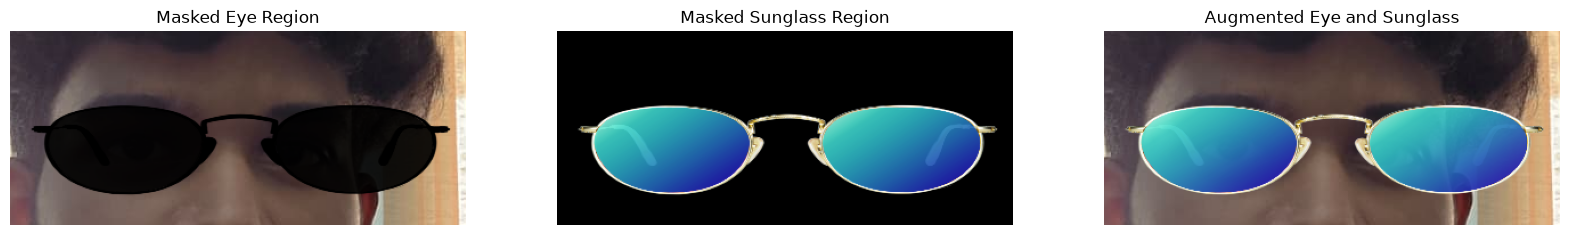

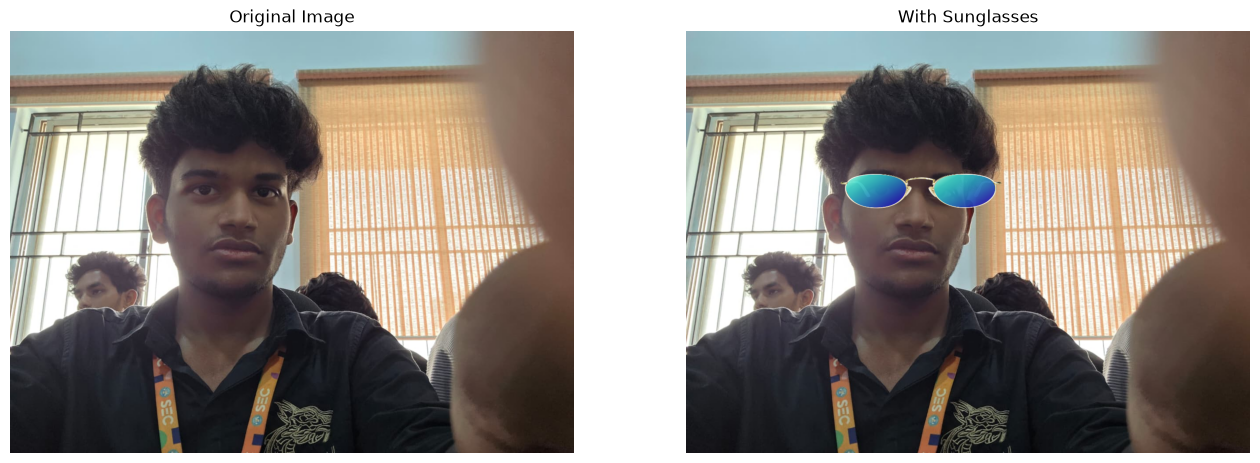

Saved as output_with_glasses.jpg


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read face image
faceImage = cv2.imread("shravinws11.jpeg")

# Read sunglasses PNG with alpha channel
glassPNG = cv2.imread("sung.png", cv2.IMREAD_UNCHANGED)

# Check images
if faceImage is None:
    print("Face image not found")
elif glassPNG is None:
    print("Sunglasses image not found")
else:

    # Position of sunglasses
    x = 330
    y = 260
    w = 400
    h = 170

    # Copy original image
    faceWithGlassesArithmetic = faceImage.copy()

    # Get image size
    imageHeight, imageWidth = faceImage.shape[:2]

    # Make sure ROI does not go outside the image
    actualW = min(w, imageWidth - x)
    actualH = min(h, imageHeight - y)

    # Extract actual face region
    eyeROI = faceWithGlassesArithmetic[y:y+actualH, x:x+actualW]

    # Resize sunglasses to EXACTLY match eyeROI
    glassPNG = cv2.resize(glassPNG, (actualW, actualH))

    # Separate BGR and Alpha channels
    glassBGR = glassPNG[:, :, :3]
    glassMask1 = glassPNG[:, :, 3]

    # Create 3-channel mask
    glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

    # Convert everything to float
    eyeROI = eyeROI.astype(np.float32)
    glassBGR = glassBGR.astype(np.float32)
    glassMask = glassMask.astype(np.float32) / 255.0

    # Blend sunglasses with face
    maskedEye = eyeROI * (1 - glassMask)
    maskedGlass = glassBGR * glassMask

    eyeRoiFinal = maskedEye + maskedGlass

    # Convert back to uint8
    maskedEye = np.uint8(maskedEye)
    maskedGlass = np.uint8(maskedGlass)
    eyeRoiFinal = np.uint8(eyeRoiFinal)

    # Display intermediate results
    plt.figure(figsize=(20, 7))

    plt.subplot(131)
    plt.imshow(maskedEye[:, :, ::-1])
    plt.title("Masked Eye Region")
    plt.axis("off")

    plt.subplot(132)
    plt.imshow(maskedGlass[:, :, ::-1])
    plt.title("Masked Sunglass Region")
    plt.axis("off")

    plt.subplot(133)
    plt.imshow(eyeRoiFinal[:, :, ::-1])
    plt.title("Augmented Eye and Sunglass")
    plt.axis("off")

    plt.show()

    # Put sunglasses back into image
    faceWithGlassesArithmetic[y:y+actualH, x:x+actualW] = eyeRoiFinal

    # Display final result
    plt.figure(figsize=(16, 9))

    plt.subplot(121)
    plt.imshow(faceImage[:, :, ::-1])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(122)
    plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
    plt.title("With Sunglasses")
    plt.axis("off")

    plt.show()

    # Save output
    cv2.imwrite("output_with_glasses.jpg", faceWithGlassesArithmetic)

    print("Saved as output_with_glasses.jpg")